# 10 — Red neuronal MLP

Este notebook construye una primera red neuronal deliberadamente simple. El objetivo inicial no es optimizarla, sino comprender su arquitectura, su entrenamiento y sus señales de convergencia antes de comparar alternativas.

La selección y el diagnóstico se realizan exclusivamente sobre 2015–2016. El holdout temporal de 2017 permanece reservado.


## Qué representa la red

Cada neurona calcula una suma ponderada de sus entradas, agrega un sesgo y aplica una función de activación. Al apilar capas con activaciones no lineales, la red puede representar relaciones que una combinación lineal no captura.

La primera arquitectura será:

```text
Entrada preprocesada
        ↓
32 neuronas — ReLU
        ↓
16 neuronas — ReLU
        ↓
1 salida — Sigmoide
```

`MLPClassifier` utiliza internamente entropía cruzada para clasificación. La salida sigmoide produce la probabilidad de cancelación.


## Imports y resolución de la raíz


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)


In [2]:
def find_project_root(start_path=None):
    current = Path(start_path or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")


Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.features import (
    build_base_feature_set,
    build_tree_model_feature_sets,
    get_feature_types,
    make_exact_feature_groups,
)
from src.preprocessing import build_tabular_preprocessor


## Carga y división temporal


In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = normalize_text_values(combine_hotel_datasets(h1_df, h2_df))
X_reference, y = build_base_feature_set(bookings_df)
feature_sets = build_tree_model_feature_sets(X_reference)

SELECTED_SET_NAME = "Tree-pruned | 17 features"
X = feature_sets[SELECTED_SET_NAME]
X_train, X_holdout, y_train, y_holdout = make_temporal_holdout_split(
    X,
    y,
    period_values=X_reference["ArrivalDateYear"],
    validation_period=2017,
)
development_groups = make_exact_feature_groups(X_train)

display(pd.DataFrame([{
    "feature_set": SELECTED_SET_NAME,
    "development_rows": len(X_train),
    "development_cancellation_rate": y_train.mean(),
    "holdout_rows_reserved": len(X_holdout),
}]))


,feature_set,development_rows,development_cancellation_rate,holdout_rows_reserved
0,Tree-pruned | 17 features,78703,0.361854,40687


## Preprocesamiento

Las variables numéricas se imputan y estandarizan. Las categóricas se imputan y codifican con One-Hot Encoding, pero no se estandarizan después de binarizarlas. Todo el preprocesamiento se ajusta dentro del pipeline para evitar leakage entre folds.


In [5]:
numeric_features, categorical_features = get_feature_types(
    X_train, require_all_categorical=False
)
mlp_preprocessor = build_tabular_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    scale_numeric=True,
)

print(f"Variables numéricas: {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Total antes de One-Hot Encoding: {X_train.shape[1]}")


Variables numéricas: 11
Variables categóricas: 6
Total antes de One-Hot Encoding: 17


## Arquitectura inicial

Se fijan dos capas ocultas pequeñas. `relu` aporta la no linealidad; `adam` actualiza los pesos mediante gradientes adaptativos; `alpha` aplica regularización L2; y `learning_rate_init` controla el tamaño inicial de cada actualización.

Por ahora no se usa `early_stopping=True`. El modelo puede detenerse si la pérdida de entrenamiento deja de mejorar durante 15 épocas, pero no crea una validación aleatoria interna. Esto mantiene separado el análisis posterior de early stopping y evita introducir ahora una partición que ignore los grupos.


In [6]:
INITIAL_ARCHITECTURE = (32, 16)
INITIAL_ALPHA = 0.001
INITIAL_LEARNING_RATE = 0.001
INITIAL_BATCH_SIZE = 128
INITIAL_MAX_ITER = 150

initial_mlp = MLPClassifier(
    hidden_layer_sizes=INITIAL_ARCHITECTURE,
    activation="relu",
    solver="adam",
    alpha=INITIAL_ALPHA,
    batch_size=INITIAL_BATCH_SIZE,
    learning_rate_init=INITIAL_LEARNING_RATE,
    max_iter=INITIAL_MAX_ITER,
    early_stopping=False,
    n_iter_no_change=15,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
initial_mlp_pipeline = Pipeline(steps=[
    ("preprocessor", mlp_preprocessor),
    ("model", initial_mlp),
])

print(initial_mlp_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LeadTime',
                                                   'ArrivalDateYear',
                                                   'StaysInWeekendNights',
                                                   'StaysInWeekNights',
                                                   'Adults',
                                                   'PreviousCancellations',
                                                   'PreviousBookingsNotCanceled',
                                                   'DaysInWait

## Validación cruzada agrupada de la red inicial

La arquitectura fija se evalúa con los mismos cinco folds agrupados utilizados en los modelos principales. La ejecución es secuencial para no entrenar varias redes simultáneamente y evitar un consumo excesivo de memoria.


In [7]:
from src.evaluation import get_stratified_group_cross_validation

mlp_cv = get_stratified_group_cross_validation(n_splits=5)
cv_start = time.perf_counter()
initial_mlp_cv_results = cross_validate(
    estimator=initial_mlp_pipeline,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    cv=mlp_cv,
    groups=development_groups,
    n_jobs=1,
    return_train_score=True,
)
cv_elapsed = time.perf_counter() - cv_start

mlp_cv_summary = pd.DataFrame([{
    "architecture": str(INITIAL_ARCHITECTURE),
    "mean_train_roc_auc": initial_mlp_cv_results["train_score"].mean(),
    "mean_cv_roc_auc": initial_mlp_cv_results["test_score"].mean(),
    "std_cv_roc_auc": initial_mlp_cv_results["test_score"].std(),
    "train_cv_gap": (
        initial_mlp_cv_results["train_score"].mean()
        - initial_mlp_cv_results["test_score"].mean()
    ),
    "mean_fit_seconds": initial_mlp_cv_results["fit_time"].mean(),
    "total_cv_minutes": cv_elapsed / 60,
}])
display(mlp_cv_summary)
display(pd.DataFrame({
    "fold": np.arange(1, 6),
    "train_roc_auc": initial_mlp_cv_results["train_score"],
    "validation_roc_auc": initial_mlp_cv_results["test_score"],
}))


c:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\.venv\Lib\site-packages\sklea

,architecture,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_fit_seconds,total_cv_minutes
0,"(32, 16)",0.964861,0.930352,0.002911,0.03451,55.599222,4.86278


,fold,train_roc_auc,validation_roc_auc
0,1,0.965126,0.926156
1,2,0.964737,0.933918
2,3,0.965312,0.930749
3,4,0.965119,0.932903
4,5,0.964013,0.928034


## Ajuste sobre desarrollo y diagnóstico

Después de estimar la generalización mediante CV, la misma red se ajusta sobre todo 2015–2016. Este ajuste no consulta 2017. Se utiliza para inspeccionar la curva de pérdida, las épocas recorridas, la activación de salida y la cantidad de parámetros aprendidos.


In [8]:
development_fit_start = time.perf_counter()
initial_mlp_pipeline.fit(X_train, y_train)
development_fit_seconds = time.perf_counter() - development_fit_start

fitted_preprocessor = initial_mlp_pipeline.named_steps["preprocessor"]
fitted_mlp = initial_mlp_pipeline.named_steps["model"]
transformed_feature_count = len(fitted_preprocessor.get_feature_names_out())
weight_parameter_count = sum(weights.size for weights in fitted_mlp.coefs_)
bias_parameter_count = sum(bias.size for bias in fitted_mlp.intercepts_)

network_diagnostics = pd.DataFrame([{
    "input_columns_after_preprocessing": transformed_feature_count,
    "hidden_layers": str(fitted_mlp.hidden_layer_sizes),
    "output_units": fitted_mlp.n_outputs_,
    "output_activation": fitted_mlp.out_activation_,
    "epochs_completed": fitted_mlp.n_iter_,
    "final_training_loss": fitted_mlp.loss_,
    "weight_parameters": weight_parameter_count,
    "bias_parameters": bias_parameter_count,
    "total_parameters": weight_parameter_count + bias_parameter_count,
    "fit_seconds_full_development": development_fit_seconds,
}])
display(network_diagnostics)


c:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


,input_columns_after_preprocessing,hidden_layers,output_units,output_activation,epochs_completed,final_training_loss,weight_parameters,bias_parameters,total_parameters,fit_seconds_full_development
0,201,"(32, 16)",1,logistic,150,0.236207,6960,49,7009,67.955334


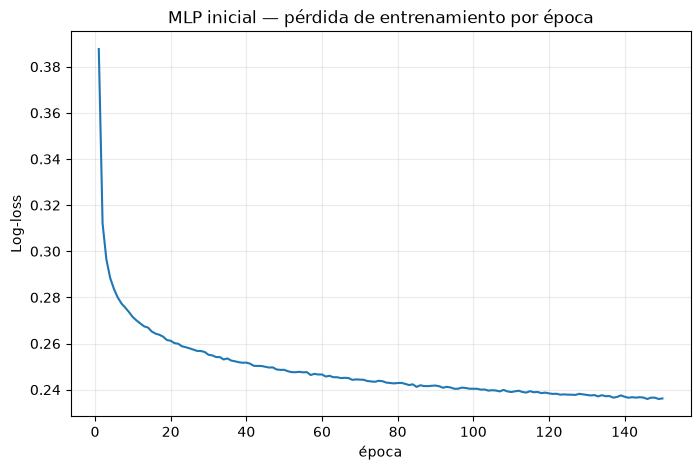

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(fitted_mlp.loss_curve_) + 1),
    fitted_mlp.loss_curve_,
    color="tab:blue",
)
ax.set_title("MLP inicial — pérdida de entrenamiento por época")
ax.set_xlabel("época")
ax.set_ylabel("Log-loss")
ax.grid(alpha=0.25)
plt.show()


## Resultado de la red inicial

La arquitectura `(32, 16)` alcanzo ROC AUC medio de entrenamiento 0,964861 y ROC AUC CV 0,930352, con desviación 0,002911. El gap train-CV de 0,034510 muestra cierto sobreajuste, aunque la red es estable entre folds y supera a Logistic Regression y al arbol de decisión en validación interna.

Los seis ajustes realizados llegaron al máximo de 150 épocas sin satisfacer el criterio de convergencia. Esto indica que la pérdida de entrenamiento continuaba mejorando, pero no demuestra que la validación externa siguiera la misma tendencia. Por ello se compara ahora la misma red con early stopping, sin modificar simultaneamente arquitectura, regularizacion, learning rate ni batch size.


## Experimento de early stopping

`MLPClassifier` reserva internamente una fraccion aleatoria de los datos recibidos por cada fold. Si el score de esa partición no mejora durante 15 épocas, restaura los pesos de la mejor época y detiene el entrenamiento antes del máximo de 300.

Esta implementacion tiene dos limitaciónes relevantes:

1. La partición interna no respeta los grupos de reservas repetidas.
2. Scikit-learn decide la detención mediante Accuracy, aunque nuestra métrica de selección externa sea ROC AUC.

La comparación principal sigue siendo metodológicamente valida porque cada estimador se evalua sobre un fold externo agrupado que no participo en su ajuste. Sin embargo, esas limitaciónes se documentan y se tendran en cuenta al interpretar el resultado.


In [10]:
from sklearn.base import clone

early_stopping_mlp_pipeline = clone(initial_mlp_pipeline).set_params(
    model__max_iter=300,
    model__early_stopping=True,
    model__validation_fraction=0.15,
    model__n_iter_no_change=15,
)

print(early_stopping_mlp_pipeline.named_steps["model"])


MLPClassifier(alpha=0.001, batch_size=128, early_stopping=True,
              hidden_layer_sizes=(32, 16), max_iter=300, n_iter_no_change=15,
              random_state=42, validation_fraction=0.15)


In [11]:
early_cv_start = time.perf_counter()
early_stopping_cv_results = cross_validate(
    estimator=early_stopping_mlp_pipeline,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    cv=mlp_cv,
    groups=development_groups,
    n_jobs=1,
    return_train_score=True,
    return_estimator=True,
)
early_cv_elapsed = time.perf_counter() - early_cv_start

early_estimators = early_stopping_cv_results["estimator"]
early_epochs = np.array([
    estimator.named_steps["model"].n_iter_
    for estimator in early_estimators
])
early_best_internal_accuracy = np.array([
    max(estimator.named_steps["model"].validation_scores_)
    for estimator in early_estimators
])

early_stopping_summary = pd.DataFrame([{
    "architecture": str(INITIAL_ARCHITECTURE),
    "early_stopping": True,
    "mean_train_roc_auc": early_stopping_cv_results["train_score"].mean(),
    "mean_cv_roc_auc": early_stopping_cv_results["test_score"].mean(),
    "std_cv_roc_auc": early_stopping_cv_results["test_score"].std(),
    "train_cv_gap": (
        early_stopping_cv_results["train_score"].mean()
        - early_stopping_cv_results["test_score"].mean()
    ),
    "mean_epochs": early_epochs.mean(),
    "min_epochs": early_epochs.min(),
    "max_epochs": early_epochs.max(),
    "mean_fit_seconds": early_stopping_cv_results["fit_time"].mean(),
    "total_cv_minutes": early_cv_elapsed / 60,
}])
display(early_stopping_summary)


,architecture,early_stopping,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,min_epochs,max_epochs,mean_fit_seconds,total_cv_minutes
0,"(32, 16)",True,0.958398,0.93321,0.001619,0.025188,64.6,53,78,19.52333,1.853205


In [12]:
fixed_training_summary = pd.DataFrame([{
    "strategy": "150 épocas; sin early stopping",
    "mean_train_roc_auc": initial_mlp_cv_results["train_score"].mean(),
    "mean_cv_roc_auc": initial_mlp_cv_results["test_score"].mean(),
    "std_cv_roc_auc": initial_mlp_cv_results["test_score"].std(),
    "train_cv_gap": (
        initial_mlp_cv_results["train_score"].mean()
        - initial_mlp_cv_results["test_score"].mean()
    ),
    "mean_epochs": INITIAL_MAX_ITER,
    "mean_fit_seconds": initial_mlp_cv_results["fit_time"].mean(),
}])
early_training_summary = pd.DataFrame([{
    "strategy": "Early stopping; máximo 300 épocas",
    "mean_train_roc_auc": early_stopping_cv_results["train_score"].mean(),
    "mean_cv_roc_auc": early_stopping_cv_results["test_score"].mean(),
    "std_cv_roc_auc": early_stopping_cv_results["test_score"].std(),
    "train_cv_gap": (
        early_stopping_cv_results["train_score"].mean()
        - early_stopping_cv_results["test_score"].mean()
    ),
    "mean_epochs": early_epochs.mean(),
    "mean_fit_seconds": early_stopping_cv_results["fit_time"].mean(),
}])
training_strategy_comparison = pd.concat(
    [fixed_training_summary, early_training_summary], ignore_index=True
)
display(training_strategy_comparison)

fold_strategy_comparison = pd.DataFrame({
    "fold": np.arange(1, 6),
    "fixed_cv_roc_auc": initial_mlp_cv_results["test_score"],
    "early_stopping_cv_roc_auc": early_stopping_cv_results["test_score"],
    "roc_auc_difference": (
        early_stopping_cv_results["test_score"]
        - initial_mlp_cv_results["test_score"]
    ),
    "early_stopping_epochs": early_epochs,
    "best_internal_accuracy": early_best_internal_accuracy,
})
display(fold_strategy_comparison)


,strategy,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,mean_fit_seconds
0,150 épocas; sin early stopping,0.964861,0.930352,0.002911,0.034510,150.0,55.599222
1,Early stopping; máximo 300 épocas,0.958398,0.933210,0.001619,0.025188,64.6,19.523330


,fold,fixed_cv_roc_auc,early_stopping_cv_roc_auc,roc_auc_difference,early_stopping_epochs,best_internal_accuracy
0,1,0.926156,0.930673,0.004517,53,0.878560
1,2,0.933918,0.935330,0.001412,64,0.873372
2,3,0.930749,0.933044,0.002295,78,0.876760
3,4,0.932903,0.934496,0.001593,53,0.882901
4,5,0.928034,0.932507,0.004473,75,0.885442


## Curvas del ajuste completo con early stopping

El ajuste sobre todo desarrollo permite observar la pérdida de entrenamiento y la Accuracy de la validación interna utilizada automáticamente para detenerse. Todavia no se consulta el holdout temporal.


In [13]:
early_development_start = time.perf_counter()
early_stopping_mlp_pipeline.fit(X_train, y_train)
early_development_seconds = time.perf_counter() - early_development_start

fitted_early_mlp = early_stopping_mlp_pipeline.named_steps["model"]
early_development_diagnostics = pd.DataFrame([{
    "epochs_completed": fitted_early_mlp.n_iter_,
    "best_internal_accuracy": fitted_early_mlp.best_validation_score_,
    "final_training_loss": fitted_early_mlp.loss_,
    "fit_seconds": early_development_seconds,
}])
display(early_development_diagnostics)


,epochs_completed,best_internal_accuracy,final_training_loss,fit_seconds
0,51,0.877435,0.245894,19.817685


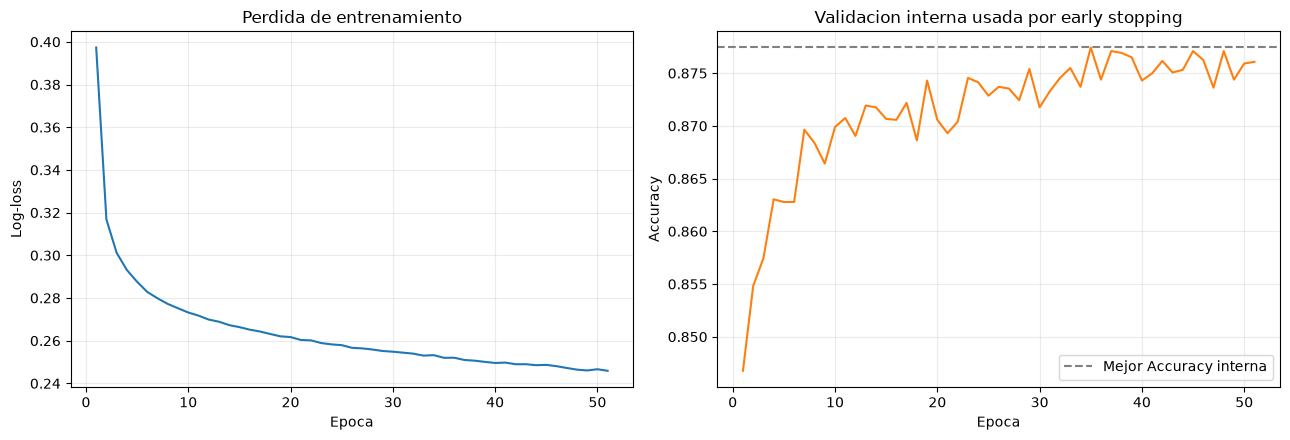

In [14]:
epochs = np.arange(1, fitted_early_mlp.n_iter_ + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs, fitted_early_mlp.loss_curve_, color="tab:blue")
axes[0].set_title("Perdida de entrenamiento")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Log-loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    epochs,
    fitted_early_mlp.validation_scores_,
    color="tab:orange",
)
axes[1].axhline(
    fitted_early_mlp.best_validation_score_,
    color="grey",
    linestyle="--",
    label="Mejor Accuracy interna",
)
axes[1].set_title("Validacion interna usada por early stopping")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Decision sobre early stopping

Early stopping mejora el ROC AUC externo en los cinco folds: la media aumenta de 0,930352 a 0,933210, la desviación baja de 0,002911 a 0,001619 y el gap train-CV se reduce de 0,034510 a 0,025188. Además, utiliza 64,6 épocas en promedio y reduce claramente el tiempo de ajuste.

Se conserva para los experimentos siguientes. Su validación interna aleatoria y basada en Accuracy permanece documentada como limitación, pero la mejora consistente sobre folds externos agrupados indica que la detención temprana reduce sobreajuste en esta red.


## Comparacion de arquitecturas

Se compara una progresión pequeña de capacidad manteniendo constantes preprocesamiento, activación ReLU, Adam, `alpha`, learning rate, batch size y early stopping:

- `(16,)`: una única capa pequeña;
- `(32,)`: una única capa con la anchura inicial de la referencia;
- `(32,16)`: referencia actual de dos capas;
- `(64,32)`: dos capas con más capacidad.

La referencia `(32,16)` reutiliza el resultado anterior. Las otras tres arquitecturas se evaluan sobre exactamente los mismos folds externos agrupados.


In [15]:
ARCHITECTURE_CANDIDATES = [(16,), (32,), (64, 32)]

architecture_results = {
    INITIAL_ARCHITECTURE: {
        "train_score": early_stopping_cv_results["train_score"],
        "test_score": early_stopping_cv_results["test_score"],
        "fit_time": early_stopping_cv_results["fit_time"],
        "epochs": early_epochs,
        "elapsed_minutes": early_cv_elapsed / 60,
    }
}

for architecture in ARCHITECTURE_CANDIDATES:
    candidate_pipeline = clone(early_stopping_mlp_pipeline).set_params(
        model__hidden_layer_sizes=architecture
    )
    candidate_start = time.perf_counter()
    candidate_cv_results = cross_validate(
        estimator=candidate_pipeline,
        X=X_train,
        y=y_train,
        scoring="roc_auc",
        cv=mlp_cv,
        groups=development_groups,
        n_jobs=1,
        return_train_score=True,
        return_estimator=True,
    )
    candidate_elapsed = time.perf_counter() - candidate_start
    candidate_estimators = candidate_cv_results.pop("estimator")
    candidate_epochs = np.array([
        estimator.named_steps["model"].n_iter_
        for estimator in candidate_estimators
    ])
    architecture_results[architecture] = {
        "train_score": candidate_cv_results["train_score"],
        "test_score": candidate_cv_results["test_score"],
        "fit_time": candidate_cv_results["fit_time"],
        "epochs": candidate_epochs,
        "elapsed_minutes": candidate_elapsed / 60,
    }
    print(
        f"Arquitectura {architecture}: "
        f"ROC AUC CV={candidate_cv_results['test_score'].mean():.6f}; "
        f"épocas medias={candidate_epochs.mean():.1f}; "
        f"tiempo={candidate_elapsed / 60:.2f} min"
    )


Arquitectura (16,): ROC AUC CV=0.931741; épocas medias=64.0; tiempo=1.36 min
Arquitectura (32,): ROC AUC CV=0.934100; épocas medias=64.8; tiempo=1.51 min
Arquitectura (64, 32): ROC AUC CV=0.931676; épocas medias=44.6; tiempo=1.99 min


In [16]:
architecture_summary_rows = []
architecture_fold_rows = []

for architecture, results in architecture_results.items():
    mean_train = results["train_score"].mean()
    mean_validation = results["test_score"].mean()
    architecture_summary_rows.append({
        "architecture": str(architecture),
        "hidden_layers": len(architecture),
        "hidden_units": sum(architecture),
        "mean_train_roc_auc": mean_train,
        "mean_cv_roc_auc": mean_validation,
        "std_cv_roc_auc": results["test_score"].std(),
        "train_cv_gap": mean_train - mean_validation,
        "mean_epochs": results["epochs"].mean(),
        "mean_fit_seconds": results["fit_time"].mean(),
        "total_cv_minutes": results["elapsed_minutes"],
    })
    for fold_index, (score, epochs_used) in enumerate(
        zip(results["test_score"], results["epochs"]), start=1
    ):
        architecture_fold_rows.append({
            "fold": fold_index,
            "architecture": str(architecture),
            "cv_roc_auc": score,
            "epochs": epochs_used,
        })

architecture_summary = (
    pd.DataFrame(architecture_summary_rows)
    .sort_values("mean_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(architecture_summary)

architecture_fold_results = pd.DataFrame(architecture_fold_rows)
architecture_fold_scores = architecture_fold_results.pivot(
    index="fold", columns="architecture", values="cv_roc_auc"
)
display(architecture_fold_scores)


,architecture,hidden_layers,hidden_units,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,mean_fit_seconds,total_cv_minutes
0,"(32,)",1,32,0.952079,0.934100,0.002440,0.017979,64.8,15.541478,1.513897
1,"(32, 16)",2,48,0.958398,0.933210,0.001619,0.025188,64.6,19.523330,1.853205
2,"(16,)",1,16,0.945556,0.931741,0.003239,0.013816,64.0,13.589803,1.356207
3,"(64, 32)",2,96,0.961935,0.931676,0.005457,0.030259,44.6,21.249733,1.994348


architecture,"(16,)","(32, 16)","(32,)","(64, 32)"
fold,,,,
1,0.927037,0.930673,0.930852,0.921169
2,0.933693,0.935330,0.937338,0.936070
3,0.931757,0.933044,0.933864,0.931615
4,0.936483,0.934496,0.936304,0.935023
5,0.929735,0.932507,0.932145,0.934500


## Decision de arquitectura

Se selecciona `(32,)`: obtuvo el mayor ROC AUC CV (0,934100), redujo el gap frente a `(32,16)` y requiere menos parámetros y tiempo. La red `(64,32)` aumentó el ajuste de train, pero presentó peor media, mayor dispersión y el mayor gap. Agregar capacidad no mejoró la generalización.

Los experimentos siguientes mantienen una unica capa oculta de 32 neuronas y early stopping. El holdout 2017 continúa reservado.


## Comparacion de regularización L2 (`alpha`)

`alpha` agrega a la función de pérdida una penalización proporcional al cuadrado de los pesos. Un valor pequeño permite una frontera más flexible, mientras que un valor alto favorece pesos menores y una función más suave. Si la penalización es excesiva, la red puede dejar de capturar relaciones útiles.

Se comparan valores separados por órdenes de magnitud: `0.0001`, `0.001`, `0.01` y `0.1`. El resultado de `0.001` con arquitectura `(32,)` ya existe y se reutiliza. Todos los demás componentes permanecen fijos.


In [17]:
SELECTED_ARCHITECTURE = (32,)
REFERENCE_ALPHA = INITIAL_ALPHA
ALPHA_CANDIDATES = [0.0001, 0.01, 0.1]

selected_architecture_results = architecture_results[SELECTED_ARCHITECTURE]
alpha_results = {
    REFERENCE_ALPHA: {
        "train_score": selected_architecture_results["train_score"],
        "test_score": selected_architecture_results["test_score"],
        "fit_time": selected_architecture_results["fit_time"],
        "epochs": selected_architecture_results["epochs"],
        "elapsed_minutes": selected_architecture_results["elapsed_minutes"],
    }
}

for alpha_value in ALPHA_CANDIDATES:
    candidate_pipeline = clone(early_stopping_mlp_pipeline).set_params(
        model__hidden_layer_sizes=SELECTED_ARCHITECTURE,
        model__alpha=alpha_value,
    )
    candidate_start = time.perf_counter()
    candidate_cv_results = cross_validate(
        estimator=candidate_pipeline,
        X=X_train,
        y=y_train,
        scoring="roc_auc",
        cv=mlp_cv,
        groups=development_groups,
        n_jobs=1,
        return_train_score=True,
        return_estimator=True,
    )
    candidate_elapsed = time.perf_counter() - candidate_start
    candidate_estimators = candidate_cv_results.pop("estimator")
    candidate_epochs = np.array([
        estimator.named_steps["model"].n_iter_
        for estimator in candidate_estimators
    ])
    alpha_results[alpha_value] = {
        "train_score": candidate_cv_results["train_score"],
        "test_score": candidate_cv_results["test_score"],
        "fit_time": candidate_cv_results["fit_time"],
        "epochs": candidate_epochs,
        "elapsed_minutes": candidate_elapsed / 60,
    }
    print(
        f"Alpha {alpha_value:g}: "
        f"ROC AUC CV={candidate_cv_results['test_score'].mean():.6f}; "
        f"épocas medias={candidate_epochs.mean():.1f}; "
        f"tiempo={candidate_elapsed / 60:.2f} min"
    )


Alpha 0.0001: ROC AUC CV=0.934590; épocas medias=72.4; tiempo=1.80 min
Alpha 0.01: ROC AUC CV=0.935171; épocas medias=61.6; tiempo=1.58 min
Alpha 0.1: ROC AUC CV=0.934071; épocas medias=65.4; tiempo=1.64 min


In [18]:
alpha_summary_rows = []
alpha_fold_rows = []

for alpha_value, results in alpha_results.items():
    mean_train = results["train_score"].mean()
    mean_validation = results["test_score"].mean()
    alpha_summary_rows.append({
        "alpha": alpha_value,
        "mean_train_roc_auc": mean_train,
        "mean_cv_roc_auc": mean_validation,
        "std_cv_roc_auc": results["test_score"].std(),
        "train_cv_gap": mean_train - mean_validation,
        "mean_epochs": results["epochs"].mean(),
        "mean_fit_seconds": results["fit_time"].mean(),
        "total_cv_minutes": results["elapsed_minutes"],
    })
    for fold_index, (score, epochs_used) in enumerate(
        zip(results["test_score"], results["epochs"]), start=1
    ):
        alpha_fold_rows.append({
            "fold": fold_index,
            "alpha": alpha_value,
            "cv_roc_auc": score,
            "epochs": epochs_used,
        })

alpha_summary = (
    pd.DataFrame(alpha_summary_rows)
    .sort_values("mean_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(alpha_summary)

alpha_fold_results = pd.DataFrame(alpha_fold_rows)
alpha_fold_scores = alpha_fold_results.pivot(
    index="fold", columns="alpha", values="cv_roc_auc"
)
display(alpha_fold_scores)


,alpha,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,mean_fit_seconds,total_cv_minutes
0,0.0100,0.950781,0.935171,0.001574,0.015611,61.6,16.013519,1.582365
1,0.0001,0.952717,0.934590,0.002064,0.018127,72.4,18.904002,1.798095
2,0.0010,0.952079,0.934100,0.002440,0.017979,64.8,15.541478,1.513897
3,0.1000,0.944584,0.934071,0.001964,0.010513,65.4,16.954037,1.640843


alpha,0.0001,0.0010,0.0100,0.1000
fold,,,,
1,0.933275,0.930852,0.934415,0.931929
2,0.937372,0.937338,0.937597,0.937375
3,0.934679,0.933864,0.934286,0.934935
4,0.936115,0.936304,0.936332,0.933760
5,0.931509,0.932145,0.933223,0.932358


## Decision de `alpha`

Se seleccióna `alpha=0.01`. Obtuvo ROC AUC CV 0,935171, ganó cuatro de cinco folds y redujo tanto la desviación como el gap frente a `0.001`. La regularización menor aumentó el ajuste de train sin mejorar tanto validación; `0.1` redujo aún más el gap, pero dejó de mejorar la métrica externa y mostró señales de underfitting.

Los experimentos siguientes mantienen `alpha=0.01`. El holdout 2017 continúa reservado.


## Comparacion de `learning_rate_init`

Este parametro define el tamaño inicial de las actualizaciónes realizadas por Adam. Un valor muy pequeño puede necesitar muchas épocas y detenerse antes de llegar a una buena solución. Un valor demásiado alto puede producir saltos inestables alrededor del mínimo o deteriorar la generalización.

Se comparan `0.0003`, `0.001`, `0.003` y `0.01`. El resultado de `0.001` con arquitectura `(32,)` y `alpha=0.01` ya existe y se reutiliza. Batch size permanece fijo en 128 para aislar el efecto.


In [19]:
SELECTED_ALPHA = 0.01
REFERENCE_LEARNING_RATE = INITIAL_LEARNING_RATE
LEARNING_RATE_CANDIDATES = [0.0003, 0.003, 0.01]

selected_alpha_results = alpha_results[SELECTED_ALPHA]
learning_rate_results = {
    REFERENCE_LEARNING_RATE: {
        "train_score": selected_alpha_results["train_score"],
        "test_score": selected_alpha_results["test_score"],
        "fit_time": selected_alpha_results["fit_time"],
        "epochs": selected_alpha_results["epochs"],
        "elapsed_minutes": selected_alpha_results["elapsed_minutes"],
    }
}

for learning_rate_value in LEARNING_RATE_CANDIDATES:
    candidate_pipeline = clone(early_stopping_mlp_pipeline).set_params(
        model__hidden_layer_sizes=SELECTED_ARCHITECTURE,
        model__alpha=SELECTED_ALPHA,
        model__learning_rate_init=learning_rate_value,
    )
    candidate_start = time.perf_counter()
    candidate_cv_results = cross_validate(
        estimator=candidate_pipeline,
        X=X_train,
        y=y_train,
        scoring="roc_auc",
        cv=mlp_cv,
        groups=development_groups,
        n_jobs=1,
        return_train_score=True,
        return_estimator=True,
    )
    candidate_elapsed = time.perf_counter() - candidate_start
    candidate_estimators = candidate_cv_results.pop("estimator")
    candidate_epochs = np.array([
        estimator.named_steps["model"].n_iter_
        for estimator in candidate_estimators
    ])
    learning_rate_results[learning_rate_value] = {
        "train_score": candidate_cv_results["train_score"],
        "test_score": candidate_cv_results["test_score"],
        "fit_time": candidate_cv_results["fit_time"],
        "epochs": candidate_epochs,
        "elapsed_minutes": candidate_elapsed / 60,
    }
    print(
        f"Learning rate {learning_rate_value:g}: "
        f"ROC AUC CV={candidate_cv_results['test_score'].mean():.6f}; "
        f"épocas medias={candidate_epochs.mean():.1f}; "
        f"tiempo={candidate_elapsed / 60:.2f} min"
    )


Learning rate 0.0003: ROC AUC CV=0.933982; épocas medias=95.4; tiempo=2.12 min
Learning rate 0.003: ROC AUC CV=0.934973; épocas medias=46.2; tiempo=1.15 min
Learning rate 0.01: ROC AUC CV=0.934819; épocas medias=41.2; tiempo=1.05 min


In [20]:
learning_rate_summary_rows = []
learning_rate_fold_rows = []

for learning_rate_value, results in learning_rate_results.items():
    mean_train = results["train_score"].mean()
    mean_validation = results["test_score"].mean()
    learning_rate_summary_rows.append({
        "learning_rate_init": learning_rate_value,
        "mean_train_roc_auc": mean_train,
        "mean_cv_roc_auc": mean_validation,
        "std_cv_roc_auc": results["test_score"].std(),
        "train_cv_gap": mean_train - mean_validation,
        "mean_epochs": results["epochs"].mean(),
        "mean_fit_seconds": results["fit_time"].mean(),
        "total_cv_minutes": results["elapsed_minutes"],
    })
    for fold_index, (score, epochs_used) in enumerate(
        zip(results["test_score"], results["epochs"]), start=1
    ):
        learning_rate_fold_rows.append({
            "fold": fold_index,
            "learning_rate_init": learning_rate_value,
            "cv_roc_auc": score,
            "epochs": epochs_used,
        })

learning_rate_summary = (
    pd.DataFrame(learning_rate_summary_rows)
    .sort_values("mean_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(learning_rate_summary)

learning_rate_fold_results = pd.DataFrame(learning_rate_fold_rows)
learning_rate_fold_scores = learning_rate_fold_results.pivot(
    index="fold", columns="learning_rate_init", values="cv_roc_auc"
)
display(learning_rate_fold_scores)


,learning_rate_init,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,mean_fit_seconds,total_cv_minutes
0,0.0010,0.950781,0.935171,0.001574,0.015611,61.6,16.013519,1.582365
1,0.0030,0.952076,0.934973,0.002372,0.017103,46.2,11.189754,1.145182
2,0.0100,0.949678,0.934819,0.001584,0.014859,41.2,10.064032,1.048088
3,0.0003,0.947179,0.933982,0.001901,0.013197,95.4,22.828939,2.118889


learning_rate_init,0.0003,0.0010,0.0030,0.0100
fold,,,,
1,0.933026,0.934415,0.933015,0.932514
2,0.936551,0.937597,0.939291,0.937253
3,0.934378,0.934286,0.934768,0.935183
4,0.935024,0.936332,0.935175,0.935298
5,0.930931,0.933223,0.932614,0.933845


## Decision de learning rate

Se conserva `learning_rate_init=0.001`. Obtuvo el mayor ROC AUC CV (0,935171). `0.003` quedó 0,000198 por debajo y entrenó más rápido, pero presentó mayor dispersión y gap. `0.01` redujo aún más el tiempo con una diferencia pequeña, aúnque tampoco mejoró la métrica principal.

Dado que el objetivo es maximizar ROC AUC y el costo sigue siendo manejable, no se sacrifica resultado por velocidad en esta etapa. El holdout 2017 continúa reservado.


## Comparacion de batch size

Batch size es el número de observaciones utilizado para estimar el gradiente antes de cada actualización de pesos. Una época siempre recorre todo el conjunto, pero cambia cuántas actualizaciónes se realizan dentro de ella.

- Un batch pequeño produce gradientes más ruidosos y muchas actualizaciónes; ese ruido puede ayudar a generalizar, pero aumenta el costo.
- Un batch grande produce gradientes más estables y menos actualizaciónes; puede ser más rápido, aunque a veces converge hacia soluciones que generalizan peor.

Se comparan `32`, `64`, `128` y `256`. El resultado de `128` ya existe y se reutiliza. Arquitectura, `alpha`, learning rate y early stopping permanecen fijos.


In [21]:
SELECTED_LEARNING_RATE = 0.001
REFERENCE_BATCH_SIZE = INITIAL_BATCH_SIZE
BATCH_SIZE_CANDIDATES = [32, 64, 256]

selected_learning_rate_results = learning_rate_results[SELECTED_LEARNING_RATE]
batch_size_results = {
    REFERENCE_BATCH_SIZE: {
        "train_score": selected_learning_rate_results["train_score"],
        "test_score": selected_learning_rate_results["test_score"],
        "fit_time": selected_learning_rate_results["fit_time"],
        "epochs": selected_learning_rate_results["epochs"],
        "elapsed_minutes": selected_learning_rate_results["elapsed_minutes"],
    }
}

for batch_size_value in BATCH_SIZE_CANDIDATES:
    candidate_pipeline = clone(early_stopping_mlp_pipeline).set_params(
        model__hidden_layer_sizes=SELECTED_ARCHITECTURE,
        model__alpha=SELECTED_ALPHA,
        model__learning_rate_init=SELECTED_LEARNING_RATE,
        model__batch_size=batch_size_value,
    )
    candidate_start = time.perf_counter()
    candidate_cv_results = cross_validate(
        estimator=candidate_pipeline,
        X=X_train,
        y=y_train,
        scoring="roc_auc",
        cv=mlp_cv,
        groups=development_groups,
        n_jobs=1,
        return_train_score=True,
        return_estimator=True,
    )
    candidate_elapsed = time.perf_counter() - candidate_start
    candidate_estimators = candidate_cv_results.pop("estimator")
    candidate_epochs = np.array([
        estimator.named_steps["model"].n_iter_
        for estimator in candidate_estimators
    ])
    batch_size_results[batch_size_value] = {
        "train_score": candidate_cv_results["train_score"],
        "test_score": candidate_cv_results["test_score"],
        "fit_time": candidate_cv_results["fit_time"],
        "epochs": candidate_epochs,
        "elapsed_minutes": candidate_elapsed / 60,
    }
    print(
        f"Batch size {batch_size_value}: "
        f"ROC AUC CV={candidate_cv_results['test_score'].mean():.6f}; "
        f"épocas medias={candidate_epochs.mean():.1f}; "
        f"tiempo={candidate_elapsed / 60:.2f} min"
    )


Batch size 32: ROC AUC CV=0.935662; épocas medias=63.4; tiempo=4.31 min
Batch size 64: ROC AUC CV=0.936075; épocas medias=60.4; tiempo=2.36 min
Batch size 256: ROC AUC CV=0.934122; épocas medias=88.2; tiempo=1.31 min


In [22]:
batch_summary_rows = []
batch_fold_rows = []

for batch_size_value, results in batch_size_results.items():
    mean_train = results["train_score"].mean()
    mean_validation = results["test_score"].mean()
    batch_summary_rows.append({
        "batch_size": batch_size_value,
        "mean_train_roc_auc": mean_train,
        "mean_cv_roc_auc": mean_validation,
        "std_cv_roc_auc": results["test_score"].std(),
        "train_cv_gap": mean_train - mean_validation,
        "mean_epochs": results["epochs"].mean(),
        "mean_fit_seconds": results["fit_time"].mean(),
        "total_cv_minutes": results["elapsed_minutes"],
    })
    for fold_index, (score, epochs_used) in enumerate(
        zip(results["test_score"], results["epochs"]), start=1
    ):
        batch_fold_rows.append({
            "fold": fold_index,
            "batch_size": batch_size_value,
            "cv_roc_auc": score,
            "epochs": epochs_used,
        })

batch_summary = (
    pd.DataFrame(batch_summary_rows)
    .sort_values("mean_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(batch_summary)

batch_fold_results = pd.DataFrame(batch_fold_rows)
batch_fold_scores = batch_fold_results.pivot(
    index="fold", columns="batch_size", values="cv_roc_auc"
)
display(batch_fold_scores)


,batch_size,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,mean_fit_seconds,total_cv_minutes
0,64,0.950994,0.936075,0.002251,0.014919,60.4,25.495022,2.355250
1,32,0.950836,0.935662,0.001814,0.015175,63.4,48.993882,4.310419
2,128,0.950781,0.935171,0.001574,0.015611,61.6,16.013519,1.582365
3,256,0.952129,0.934122,0.002158,0.018007,88.2,13.197112,1.312553


batch_size,32,64,128,256
fold,,,,
1,0.936768,0.933440,0.934415,0.931257
2,0.937828,0.939881,0.937597,0.937156
3,0.936464,0.934936,0.934286,0.934464
4,0.934515,0.937202,0.936332,0.935543
5,0.932733,0.934917,0.933223,0.932189


## Decision provisional de batch size

Batch 64 obtuvo el mayor ROC AUC CV (0,936075), ganó tres de cinco folds y redujo levemente el gap frente a 128. Batch 32 también mejoró la referencia, pero necesitó casi el doble de tiempo que 64 y obtuvo una media menor. Batch 256 presentó peor ROC AUC y mayor gap.

Se seleccióna provisionalmente batch 64. Antes de cerrar la decisión se confirma su interacción con el segúndo mejor learning rate. El holdout 2017 continúa reservado.


## Confirmacion conjunta de learning rate y batch size

Learning rate y batch size interactúan: cambiar el número de observaciones por actualizacion modifica tanto el ruido del gradiente como la cantidad de actualizaciones realizadas por época. Por eso se completa una pequeña comparación `2 x 2` con los dos learning rates y los dos batches relevantes.

Tres combinaciones ya fueron evaluadas. Solo falta `learning_rate_init=0.003` con batch 64, por lo que esta sección entrena cinco redes nuevas y reutiliza todo lo demás.


In [23]:
CONFIRMATION_LEARNING_RATE = 0.003
CONFIRMATION_BATCH_SIZE = 64

confirmation_pipeline = clone(early_stopping_mlp_pipeline).set_params(
    model__hidden_layer_sizes=SELECTED_ARCHITECTURE,
    model__alpha=SELECTED_ALPHA,
    model__learning_rate_init=CONFIRMATION_LEARNING_RATE,
    model__batch_size=CONFIRMATION_BATCH_SIZE,
)
confirmation_start = time.perf_counter()
confirmation_cv_results = cross_validate(
    estimator=confirmation_pipeline,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    cv=mlp_cv,
    groups=development_groups,
    n_jobs=1,
    return_train_score=True,
    return_estimator=True,
)
confirmation_elapsed = time.perf_counter() - confirmation_start
confirmation_estimators = confirmation_cv_results.pop("estimator")
confirmation_epochs = np.array([
    estimator.named_steps["model"].n_iter_
    for estimator in confirmation_estimators
])

confirmation_missing_results = {
    "train_score": confirmation_cv_results["train_score"],
    "test_score": confirmation_cv_results["test_score"],
    "fit_time": confirmation_cv_results["fit_time"],
    "epochs": confirmation_epochs,
    "elapsed_minutes": confirmation_elapsed / 60,
}
print(
    f"Learning rate {CONFIRMATION_LEARNING_RATE:g}; "
    f"batch {CONFIRMATION_BATCH_SIZE}: "
    f"ROC AUC CV={confirmation_cv_results['test_score'].mean():.6f}; "
    f"épocas medias={confirmation_epochs.mean():.1f}; "
    f"tiempo={confirmation_elapsed / 60:.2f} min"
)


Learning rate 0.003; batch 64: ROC AUC CV=0.935474; épocas medias=48.8; tiempo=1.93 min


In [24]:
joint_results = {
    (0.001, 128): learning_rate_results[0.001],
    (0.001, 64): batch_size_results[64],
    (0.003, 128): learning_rate_results[0.003],
    (0.003, 64): confirmation_missing_results,
}

joint_summary_rows = []
joint_fold_rows = []
for (learning_rate_value, batch_size_value), results in joint_results.items():
    mean_train = results["train_score"].mean()
    mean_validation = results["test_score"].mean()
    joint_summary_rows.append({
        "learning_rate_init": learning_rate_value,
        "batch_size": batch_size_value,
        "mean_train_roc_auc": mean_train,
        "mean_cv_roc_auc": mean_validation,
        "std_cv_roc_auc": results["test_score"].std(),
        "train_cv_gap": mean_train - mean_validation,
        "mean_epochs": results["epochs"].mean(),
        "mean_fit_seconds": results["fit_time"].mean(),
    })
    label = f"lr={learning_rate_value:g}; batch={batch_size_value}"
    for fold_index, score in enumerate(results["test_score"], start=1):
        joint_fold_rows.append({
            "fold": fold_index,
            "configuration": label,
            "cv_roc_auc": score,
        })

joint_summary = (
    pd.DataFrame(joint_summary_rows)
    .sort_values("mean_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(joint_summary)

joint_fold_scores = pd.DataFrame(joint_fold_rows).pivot(
    index="fold", columns="configuration", values="cv_roc_auc"
)
display(joint_fold_scores)


,learning_rate_init,batch_size,mean_train_roc_auc,mean_cv_roc_auc,std_cv_roc_auc,train_cv_gap,mean_epochs,mean_fit_seconds
0,0.001,64,0.950994,0.936075,0.002251,0.014919,60.4,25.495022
1,0.003,64,0.951056,0.935474,0.002930,0.015582,48.8,20.595858
2,0.001,128,0.950781,0.935171,0.001574,0.015611,61.6,16.013519
3,0.003,128,0.952076,0.934973,0.002372,0.017103,46.2,11.189754


configuration,lr=0.001; batch=128,lr=0.001; batch=64,lr=0.003; batch=128,lr=0.003; batch=64
fold,,,,
1,0.934415,0.933440,0.933015,0.934163
2,0.937597,0.939881,0.939291,0.940153
3,0.934286,0.934936,0.934768,0.935756
4,0.936332,0.937202,0.935175,0.936154
5,0.933223,0.934917,0.932614,0.931143


## Decision conjunta final

Se selecciona `learning_rate_init=0.001` y batch 64. Esta combinacion obtuvo el mayor ROC AUC CV (0,936075), junto con el menor gap de las cuatro alternativas. Aumentar el learning rate a `0.003` redujo épocas, pero disminuyó la media y aumentó la dispersión tanto con batch 64 como con 128.

La búsqueda de hiperparámetros queda cerrada antes de consultar 2017. El resultado temporal se utilizará solamente para estimar generalización, no para iniciar una nueva iteración de ajuste.


## Modelo final y evalúacion temporal única

Con arquitectura e hiperparámetros cerrados, el pipeline se reajusta sobre todo 2015–2016 y se evalúa una única vez sobre 2017. El threshold permanece en 0,5 para mantener la comparación técnica con los modelos anteriores. El resultado del holdout no se utilizará para reabrir la búsqueda.


In [26]:
from sklearn.metrics import RocCurveDisplay

from src.evaluation import evaluate_binary_classifier
from src.plots import plot_confusion_matrix

FINAL_MLP_PARAMETERS = {
    "model__hidden_layer_sizes": (32,),
    "model__alpha": 0.01,
    "model__learning_rate_init": 0.001,
    "model__batch_size": 64,
    "model__max_iter": 300,
    "model__early_stopping": True,
    "model__validation_fraction": 0.15,
    "model__n_iter_no_change": 15,
}

final_mlp_pipeline = clone(early_stopping_mlp_pipeline).set_params(
    **FINAL_MLP_PARAMETERS
)
final_fit_start = time.perf_counter()
final_mlp_pipeline.fit(X_train, y_train)
final_fit_seconds = time.perf_counter() - final_fit_start

final_mlp = final_mlp_pipeline.named_steps["model"]
print(f"Epocas utilizadas: {final_mlp.n_iter_}")
print(f"Mejor Accuracy interna: {final_mlp.best_validation_score_:.6f}")
print(f"Tiempo de ajuste: {final_fit_seconds:.2f} segundos")


Epocas utilizadas: 55
Mejor Accuracy interna: 0.873031
Tiempo de ajuste: 32.06 segundos


In [27]:
final_mlp_metrics = evaluate_binary_classifier(
    final_mlp_pipeline, X_holdout, y_holdout, threshold=0.5
)

final_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression engineered",
        "cv_roc_auc": 0.908557,
        "holdout_roc_auc": 0.855017,
        "accuracy": 0.739032,
        "precision": 0.620290,
        "recall": 0.839568,
        "f1": 0.713461,
    },
    {
        "model": "Decision Tree pruned",
        "cv_roc_auc": 0.927092,
        "holdout_roc_auc": 0.838694,
        "accuracy": 0.765822,
        "precision": 0.723456,
        "recall": 0.639187,
        "f1": 0.678716,
    },
    {
        "model": "KNN (sample CV)",
        "cv_roc_auc": 0.876338,
        "holdout_roc_auc": 0.825042,
        "accuracy": 0.759751,
        "precision": 0.743475,
        "recall": 0.578914,
        "f1": 0.650955,
    },
    {
        "model": "Random Forest",
        "cv_roc_auc": 0.941260,
        "holdout_roc_auc": 0.842641,
        "accuracy": 0.769312,
        "precision": 0.748885,
        "recall": 0.607621,
        "f1": 0.670898,
    },
    {
        "model": "XGBoost regularized",
        "cv_roc_auc": 0.938277,
        "holdout_roc_auc": 0.867291,
        "accuracy": 0.781724,
        "precision": 0.737476,
        "recall": 0.676913,
        "f1": 0.705898,
    },
    {
        "model": "MLP final",
        "cv_roc_auc": 0.936075,
        "holdout_roc_auc": final_mlp_metrics["roc_auc"],
        "accuracy": final_mlp_metrics["accuracy"],
        "precision": final_mlp_metrics["precision"],
        "recall": final_mlp_metrics["recall"],
        "f1": final_mlp_metrics["f1"],
    },
]).set_index("model")
display(final_model_comparison)

print(f"Gap CV-holdout MLP: {0.936075 - final_mlp_metrics['roc_auc']:.6f}")


,cv_roc_auc,holdout_roc_auc,accuracy,precision,recall,f1
model,,,,,,
Logistic Regression engineered,0.908557,0.855017,0.739032,0.620290,0.839568,0.713461
Decision Tree pruned,0.927092,0.838694,0.765822,0.723456,0.639187,0.678716
KNN (sample CV),0.876338,0.825042,0.759751,0.743475,0.578914,0.650955
Random Forest,0.941260,0.842641,0.769312,0.748885,0.607621,0.670898
XGBoost regularized,0.938277,0.867291,0.781724,0.737476,0.676913,0.705898
MLP final,0.936075,0.845721,0.627129,0.509632,0.964433,0.666872


Gap CV-holdout MLP: 0.090354


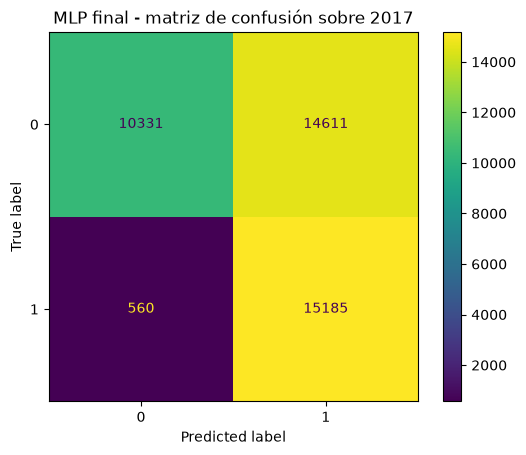

In [31]:
from importlib import reload

import src.plots as plots_module

plots_module = reload(plots_module)
plots_module.plot_confusion_matrix(
    final_mlp_pipeline,
    X_holdout,
    y_holdout,
    title="MLP final - matriz de confusión sobre 2017",
)


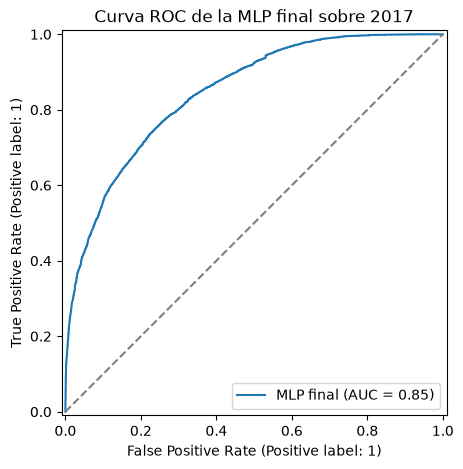

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    final_mlp_pipeline,
    X_holdout,
    y_holdout,
    name="MLP final",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("Curva ROC de la MLP final sobre 2017")
plt.show()


## Diagnostico del entrenamiento final

Estas curvas muestran la evolución de la pérdida de entrenamiento y la Accuracy de la validación interna utilizada por early stopping. Esta validación interna no es el holdout temporal.


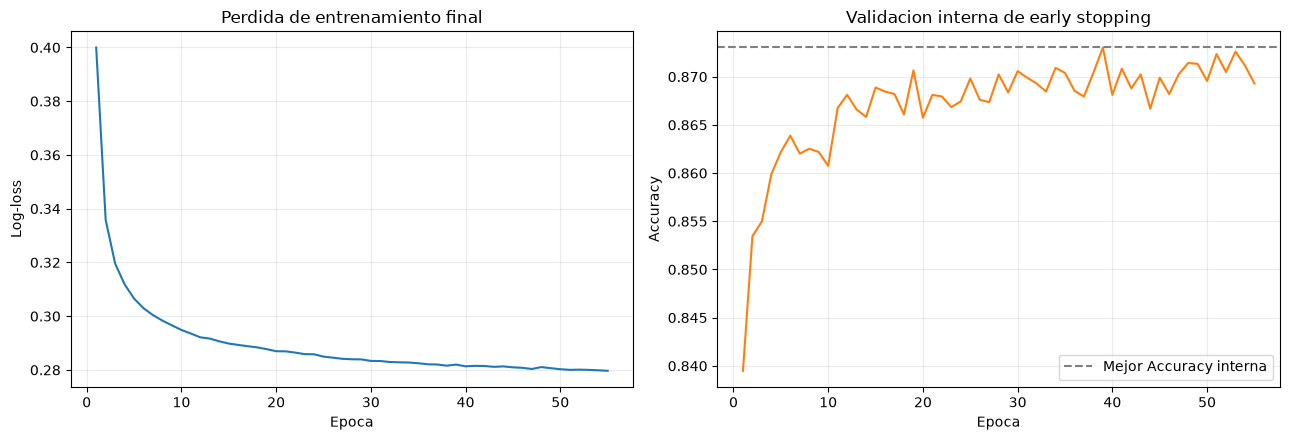

In [30]:
final_epochs = np.arange(1, final_mlp.n_iter_ + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(final_epochs, final_mlp.loss_curve_, color="tab:blue")
axes[0].set_title("Perdida de entrenamiento final")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Log-loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    final_epochs,
    final_mlp.validation_scores_,
    color="tab:orange",
)
axes[1].axhline(
    final_mlp.best_validation_score_,
    color="grey",
    linestyle="--",
    label="Mejor Accuracy interna",
)
axes[1].set_title("Validacion interna de early stopping")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Conclusiones

La MLP final utiliza una capa oculta de 32 neuronas, ReLU, Adam, `alpha=0.01`, learning rate 0,001, batch 64 y early stopping. La seleccion se realizó exclusivamente sobre 2015-2016 y alcanzo ROC AUC CV 0,936075. Early stopping redujo el gap y mejoró los cinco folds frente a 150 épocas fijas; su partición interna aleatoria y basada en Accuracy se conserva como limitación metodológica.

Sobre 2017 obtuvo ROC AUC 0,845721, Accuracy 0,627129, Precision 0,509632, Recall 0,964433 y F1 0,666872. El gap CV-holdout fue 0,090354. Con threshold 0,5 detectó 15.185 de 15.745 cancelaciones y omitió solo 560, pero genero 14.611 falsos positivos.

La red ofrece el mayor Recall de los modelos ajustados, a costa de intervenir sobre una proporción muy alta de reservas. Su ROC AUC temporal queda por debajo de Logistic Regression y XGBoost, por lo que ajustar el threshold podría cambiar el balance entre Precision y Recall, pero no convertirla en el mejor modelo de ordenamiento. XGBoost permanece como candidato tecnico principal y Logistic Regression como referencia interpretable de alto Recall. No se realizan nuevos ajustes a partir de 2017.
